In [1]:
#=========================================================
# explore_dharma_bin_ice.py
# Author: McKenna W. Stanford
# Utility: Explores output from dharma 3d runs.
#=========================================================

In [1]:
#=======================================
# Imports
#=======================================
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray
import datetime
import calendar
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib
import pickle
import pandas as pd
import os
import numpy as np
from scipy import ndimage
from scipy.ndimage import gaussian_filter
from scipy.interpolate import NearestNDInterpolator as nn
from matplotlib.patches import Rectangle
from matplotlib import cm
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

In [2]:
#=======================================
# Diagnostics Parameters
#=======================================
space = '    '
#=======================================
# Functions
#=======================================
def print_diag(key,var):
    print(key)
    print(space,'Shape:',np.shape(var))
    print(space,'Max:',np.max(var))
    print(space,'Min:',np.min(var))
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx],idx

In [6]:
cntl_ice = False
cntl_ice_hm = False
cntl_ice_ABIFM10X = False
sip_ice = False
sip_ice_hm = False
sip_ice_ABIFM10X = False
sip_10x_ice = False
sip_10x_ice_hm = True
sip_10x_ice_ABIFM10X = False
cntl_ice_noturb = False
sip_ice_noturb = False
sip_10x_ice_noturb = False

write = True

if cntl_ice:
    sim_name = 'cntl_bin_ice'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/restart/'.format(sim_name)
    title = 'CNTL BIN ICE'
    paths = [path1,path2]

if cntl_ice_hm:
    sim_name = 'cntl_bin_ice_hm'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'CNTL BIN ICE HM'
    paths = [path1,path2]
    
if cntl_ice_ABIFM10X:
    sim_name = 'cntl_bin_ice_ABIFM10X'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'CNTL BIN ICE ABIFM10X'
    paths = [path1,path2]
    
if sip_ice:
    sim_name = 'sip_bin_ice'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'SIP BIN ICE'
    paths = [path1,path2]

if sip_ice_hm:
    sim_name = 'sip_bin_ice_hm'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'SIP BIN ICE HM'
    paths = [path1,path2]
    
if sip_ice_ABIFM10X:
    sim_name = 'sip_bin_ice_ABIFM10X'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'SIP BIN ICE ABIFM10X'
    paths = [path1,path2]
    
if sip_10x_ice:
    sim_name = 'sip_10x_bin_ice'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice/'
    path2= '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'SIP 10X BIN ICE'
    paths = [path1,path2]
    
if sip_10x_ice_hm:
    sim_name = 'sip_10x_bin_ice_hm'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'SIP 10X BIN ICE HM'
    paths = [path1,path2]
    
if sip_10x_ice_ABIFM10X:
    sim_name = 'sip_10x_bin_ice_ABIFM10X'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'SIP 10X BIN ICE ABIFM10X'
    paths = [path1,path2]
    
if cntl_ice_noturb:
    sim_name = 'cntl_bin_ice_noturb'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/restart/'.format(sim_name)
    title = 'CNTL BIN ICE NOTURB'
    paths = [path1,path2]
    #paths = [path2]

if sip_ice_noturb:
    sim_name = 'sip_bin_ice_noturb'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice_noturb/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'SIP BIN ICE NOTURB'
    paths = [path1,path2]

if sip_10x_ice_noturb:
    sim_name = 'sip_10x_bin_ice_noturb'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice_noturb/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    title = 'SIP 10X BIN ICE NOTURB'
    paths = [path1,path2]

#=======================================
# Load data
#=======================================
def load_path_data(path):
    """Load sounding and scalar data from a single DHARMA output path."""
    ncfile = xarray.open_dataset(path + 'dharma.soundings.cdf')
    ncfile_scalar = xarray.open_dataset(path + 'dharma.scalars.cdf')
    rhobar = ncfile['rhobar'].values

    data = {
        'time':       ncfile['time'].values,
        'ntot_1':     ncfile['ntot_1'].values,
        'ntot_2':     ncfile['ntot_2'].values,
        'nqr':        ncfile['nqr'].values,
        'nqc':        ncfile['nqc'].values,
        'nql':        ncfile['nql'].values,
        'nd_cld':     ncfile['nd_cld'].values,
        'nc_cld':     ncfile['nc_cld'].values,
        'nr_cld':     ncfile['nr_cld'].values,
        'reff_drops': ncfile['reff_drops'].values,
        'reff_2':     ncfile['reff_2'].values,
        'ql':         ncfile['ql'].values,
        'qc':         ncfile['qc'].values,
        'qr':         ncfile['qr'].values,
        'clwc':       ncfile['qc'].values * rhobar * 1e3,
        'rwc':        ncfile['qr'].values * rhobar * 1e3,
        'lwc':        ncfile['ql'].values * rhobar * 1e3,
        'T':          ncfile['T'].values,
        'wmax':       ncfile['wmax'].values,
        'rhmax':      ncfile['RH_max'].values,
        'net_cond':   ncfile['net_cond'].values,
        'tke_smag':   ncfile['tke_smag'].values,
        'avg_T_flx':  ncfile_scalar['avg_T_flx'].values,
        'avg_qv_flx': ncfile_scalar['avg_qv_flx'].values,
        'avg_T_sfc':  ncfile_scalar['avg_T_sfc'].values,
        'avg_ustar':  ncfile_scalar['avg_ustar'].values,
        'avg_precip':  ncfile_scalar['avg_precip'].values,
        'max_precip':  ncfile_scalar['max_precip'].values,
        'rwp':        ncfile_scalar['rwp'].values,
        'clwp':       ncfile_scalar['cwp'].values,
        'lwp':        ncfile_scalar['lwp'].values,
        'max_w':      ncfile_scalar['max_w'].values,
        'cfl':        ncfile_scalar['cfl'].values,
        'iwp':         ncfile_scalar['iwp'].values,
        'iwpf':        ncfile_scalar['iwpf'].values,
        'max_qi':      ncfile_scalar['max_qi'].values,
        'max_qif':     ncfile_scalar['max_qif'].values,
        'max_sh_coag': ncfile_scalar['max_sh_coag'].values,
        #'max_sh_coag_raw': ncfile_scalar['max_sh_coag_raw'].values,
        'max_sh_in':   ncfile_scalar['max_sh_in'].values,
        'max_in_imm':   ncfile_scalar['max_in_imm'].values,
        'ntot_3':      ncfile['ntot_3'].values,
        'reff_3':      ncfile['reff_3'].values,
        'ntot_ifn':    ncfile['ntot_ifn'].values,
        'nbigice_cld': ncfile['nbigice_cld'].values,
        'nif_cld':     ncfile['nif_cld'].values,
        'nqif':        ncfile['nqif'].values,
        'qif':         ncfile['qif'].values,
        'qif2':        ncfile['qif2'].values,
        'iwc':         ncfile['qif'].values * rhobar * 1e3,
        'iwc2':        ncfile['qif2'].values * rhobar * 1e3,
        'rhimax':      ncfile['RHI_max'].values,
        'net_dep':     ncfile['net_dep'].values,
    }

    # *** THE KEY MODIFICATION IS HERE ***
    # Check if 'max_sh_coag_raw' exists. If not, create a dummy version.
    if 'max_sh_coag_raw' in ncfile_scalar.variables:
        # If it exists, load it normally.
        data['max_sh_coag_raw'] = ncfile_scalar['max_sh_coag_raw'].values
    else:
        # If it doesn't exist, create a placeholder.
        print("    -> 'max_sh_coag_raw' not found. Creating a padded array.")
        # We mimic the shape and type of 'max_sh_coag', filling it with zeros or NaNs.
        # Using np.zeros_like is a robust way to do this.
        # This ensures it has the same length as the time dimension for this segment.
        data['max_sh_coag_raw'] = np.zeros_like(data['max_sh_coag'])
        # Alternatively, you could fill with NaNs if that's more appropriate for your analysis:
        # data['max_sh_coag_raw'] = np.full_like(data['max_sh_coag'], np.nan)
    
    return data, ncfile

# Load and stitch restart files.
# The restart file takes precedence: trim the *previous* segment to stop just
# before the restart's first time step, then keep the full restart segment.
# e.g. file 1 ran to 3681s, restart begins at 3600s -> file 1 is cut at <3600s,
# restart covers 3600s onwards.
segments = []
for path in paths:
    print(path)
    d, ncfile = load_path_data(path)
    if segments:
        restart_start = d['time'][0]
        prev = segments[-1]
        mask = prev['time'] < restart_start
        segments[-1] = {k: v[mask] for k, v in prev.items()}
    segments.append(d)

# Concatenate all segments into a single dict
out_dict = {k: np.concatenate([seg[k] for seg in segments]) for k in segments[0]}

# Add static grid variables (same across restart files; taken from last loaded file)
out_dict['zt'] = ncfile['zt']
out_dict['zw'] = ncfile['zw']
out_dict['rhobar'] = ncfile['rhobar']

#==========================================
# Unpack for use in downstream cells
#==========================================
time       = out_dict['time']
ntot_1     = out_dict['ntot_1']
ntot_2     = out_dict['ntot_2']
nqr        = out_dict['nqr']
nqc        = out_dict['nqc']
nql        = out_dict['nql']
nd_cld     = out_dict['nd_cld']
nc_cld     = out_dict['nc_cld']
nr_cld     = out_dict['nr_cld']
reff_drops = out_dict['reff_drops']
reff_2     = out_dict['reff_2']
ql         = out_dict['ql']
qc         = out_dict['qc']
qr         = out_dict['qr']
clwc       = out_dict['clwc']
rwc        = out_dict['rwc']
lwc        = out_dict['lwc']
T          = out_dict['T']
wmax       = out_dict['wmax']
rhmax      = out_dict['rhmax']
net_cond   = out_dict['net_cond']
tke_smag   = out_dict['tke_smag']
avg_T_flx  = out_dict['avg_T_flx']
avg_qv_flx = out_dict['avg_qv_flx']
avg_T_sfc  = out_dict['avg_T_sfc']
avg_ustar  = out_dict['avg_ustar']
rwp        = out_dict['rwp']
clwp       = out_dict['clwp']
lwp        = out_dict['lwp']
max_w      = out_dict['max_w']
avg_precip     = out_dict['avg_precip']
max_precip     = out_dict['max_precip']
cfl        = out_dict['cfl']
zt         = ncfile['zt']
zw         = ncfile['zw']
rhobar     = ncfile['rhobar']

qif         = out_dict['qif']
qif2        = out_dict['qif2']
nqif        = out_dict['nqif']
nif_cld     = out_dict['nif_cld']
nbigice_cld = out_dict['nbigice_cld']
ntot_ifn    = out_dict['ntot_ifn']
reff_3      = out_dict['reff_3']
ntot_3      = out_dict['ntot_3']
iwc         = out_dict['iwc']
iwc2        = out_dict['iwc2']
iwp         = out_dict['iwp']
iwpf        = out_dict['iwpf']
max_qi      = out_dict['max_qi']
max_qif     = out_dict['max_qif']
rhimax      = out_dict['rhimax']
net_dep     = out_dict['net_dep']
max_sh_coag = out_dict['max_sh_coag']
max_sh_coag_raw = out_dict['max_sh_coag_raw']
max_sh_in   = out_dict['max_sh_in']

if write:
    save_path = '/pscratch/sd/m/mckenna/dharma_post/'
    file_name = f'{sim_name}_sounding_time_series.pkl'
    print(file_name)
    with open(save_path + file_name, 'wb') as f:
        pickle.dump(out_dict, f)

print('done')


/pscratch/sd/m/mckenna/dharma_output/cntl_bin_ice/
    -> 'max_sh_coag_raw' not found. Creating a padded array.
/pscratch/sd/m/mckenna/dharma_output/sip_10x_bin_ice_hm/
sip_10x_bin_ice_hm_sounding_time_series.pkl
done


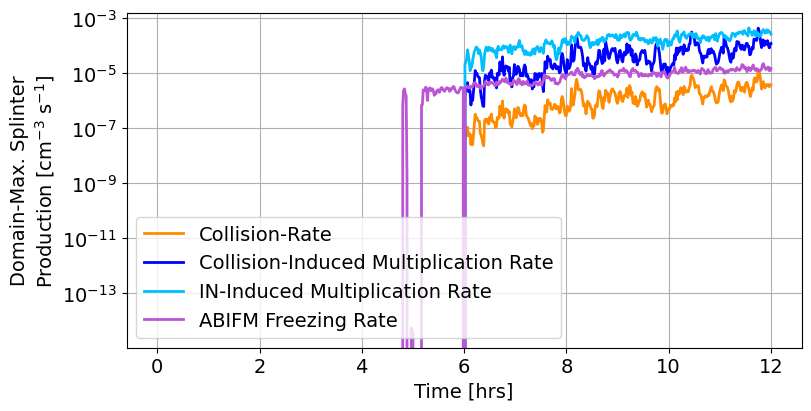

In [7]:
fig = plt.figure(figsize=(8,4),constrained_layout=True)
ax1 = fig.add_subplot(111)
axlist = [ax1]
Fontsize=14
for ax in axlist:
    ax.set_xlabel('Time [hrs]',fontsize=Fontsize)
    ax.set_ylabel('Domain-Max. Splinter\nProduction [cm$^{-3}$ s$^{-1}$]',fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    ax.grid()

ax1.plot(out_dict['time']/3600.,out_dict['max_sh_coag_raw'],lw=2,c='darkorange',label='Collision-Rate')
ax1.plot(out_dict['time']/3600.,out_dict['max_sh_coag'],lw=2,c='blue',label='Collision-Induced Multiplication Rate')
ax1.plot(out_dict['time']/3600.,out_dict['max_sh_in'],lw=2,c='deepskyblue',label='IN-Induced Multiplication Rate')
ax1.plot(out_dict['time']/3600.,out_dict['max_in_imm'],lw=2,c='mediumorchid',label='ABIFM Freezing Rate')

ax1.legend(loc='lower left',fontsize=Fontsize)
ax1.set_yscale('log')
plt.show()
plt.close()

/tmp/ipykernel_2286448/558523420.py:19: UserWarning: Log scale: values of z <= 0 have been masked
  mappable = ax.contourf(tmp_time, z, data.T, levels=levels, cmap=cmap, norm=norm, extend=extend)


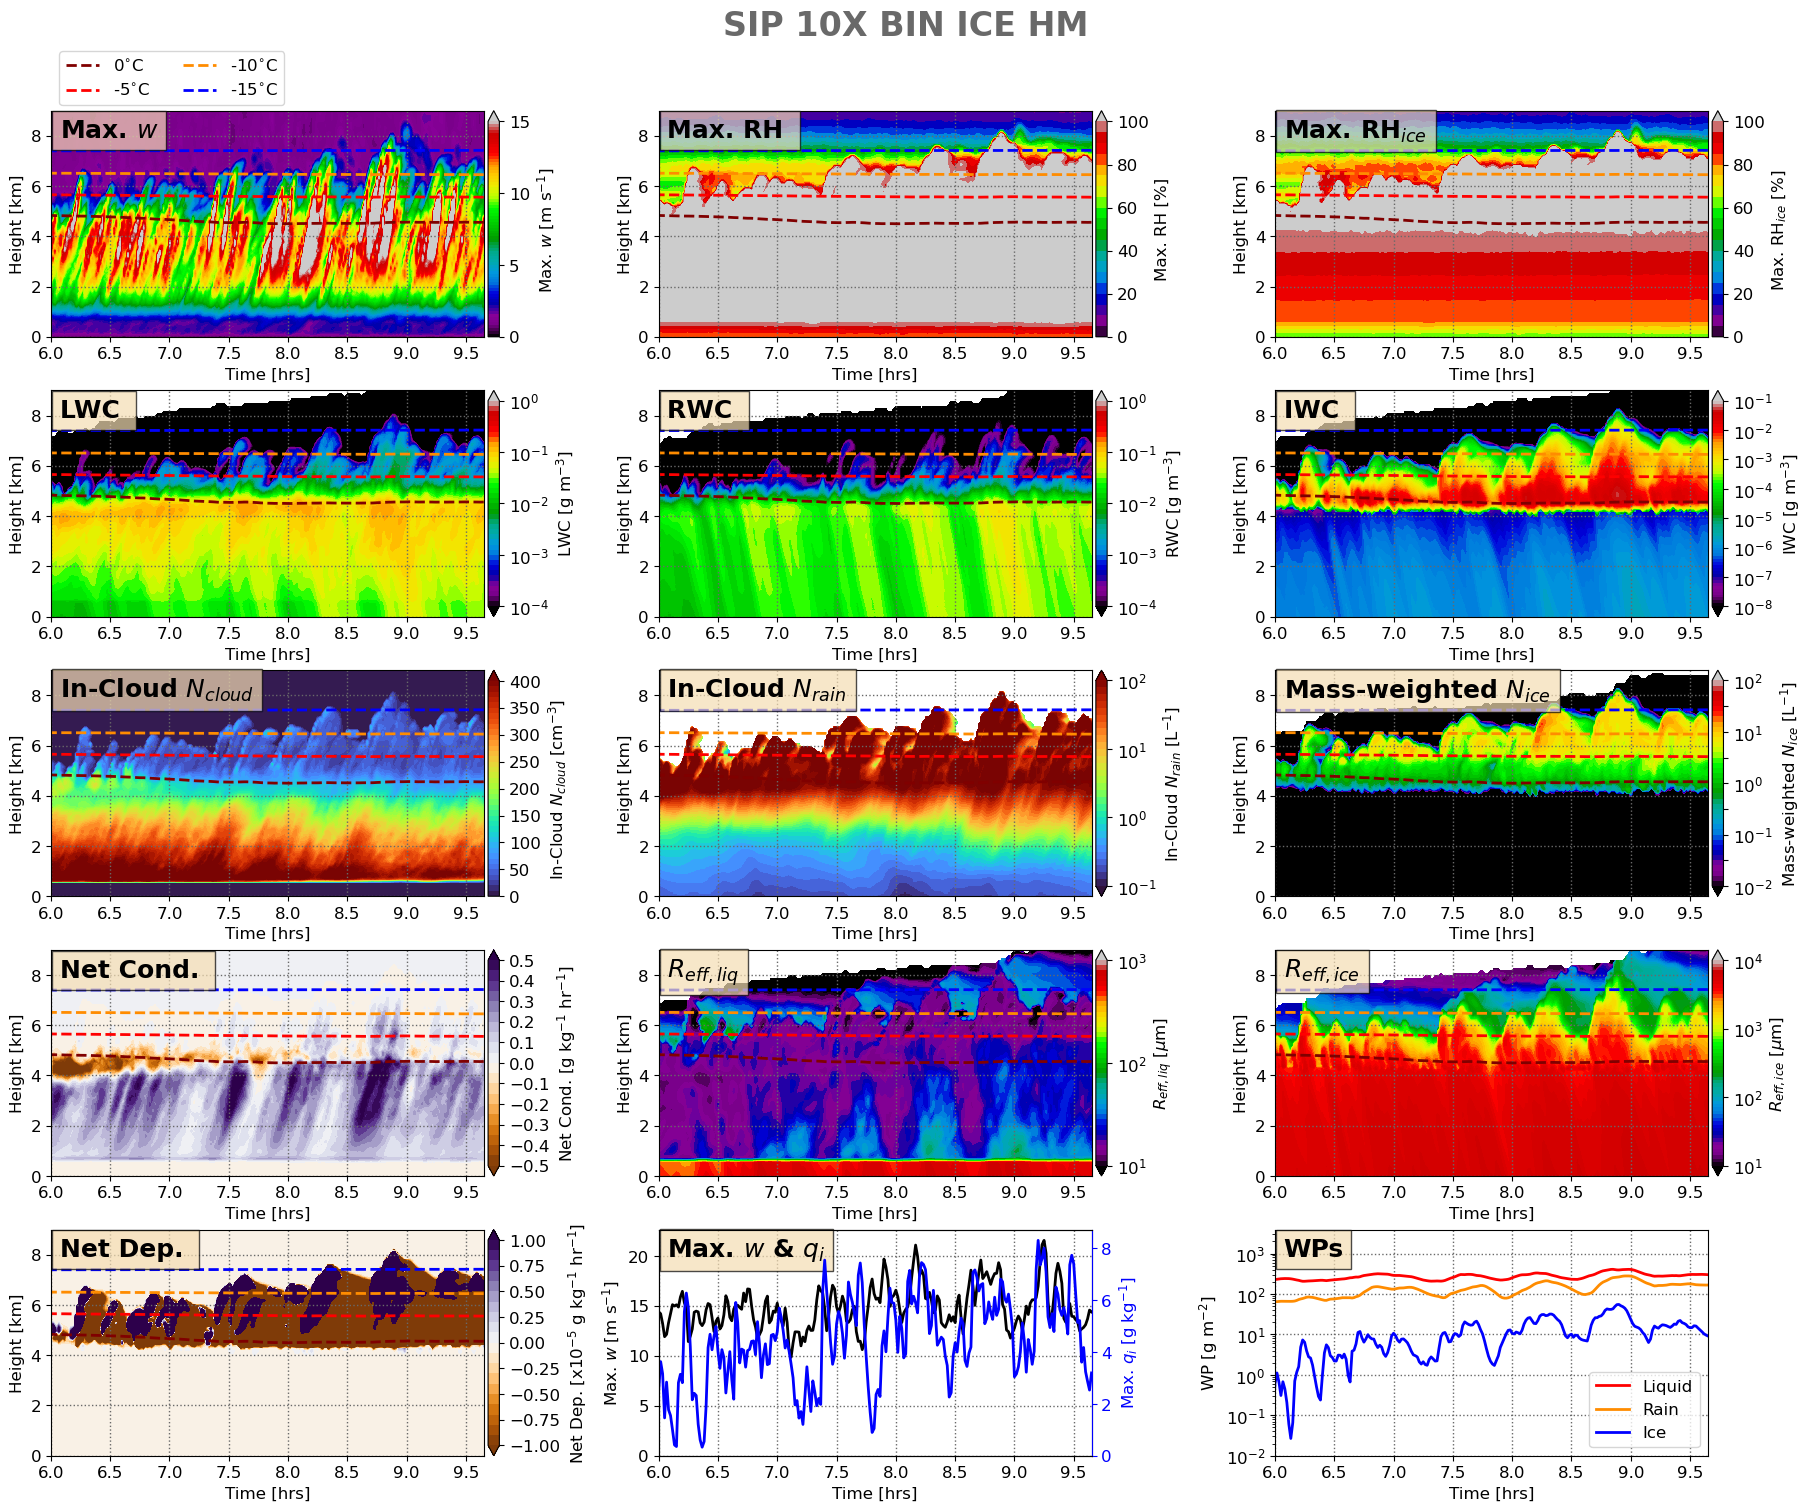

In [12]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from matplotlib.lines import Line2D

props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
left_lab = True

# --- Helper Functions ---
def setup_axes(axes, Fontsize):
    for ax in axes[:-2]:
        ax.grid(ls='dotted', lw=1, c='dimgrey')
        ax.tick_params(labelsize=Fontsize)
        ax.set_ylabel('Height [km]', fontsize=Fontsize)
        ax.set_ylim(0, 9.)
        ax.set_xlabel('Time [hrs]', fontsize=Fontsize)

def plot_panel(ax, tmp_time, z, data, levels, cmap, label, Fontsize, norm=None, extend='both', ticks=None):
    mappable = ax.contourf(tmp_time, z, data.T, levels=levels, cmap=cmap, norm=norm, extend=extend)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.01, ticks=ticks)
    cbar.ax.tick_params(labelsize=Fontsize)
    cbar.ax.set_ylabel(label, fontsize=Fontsize)
    if left_lab:
        ax.text(0.02, 0.88, label.split('[')[0], fontsize=Fontsize*1.5, fontweight='bold', c='k',
                transform=ax.transAxes, bbox=props)
    else:
        ax.text(0.98, 0.96, label.split('[')[0], fontsize=Fontsize*1.5, fontweight='bold', c='k',
                transform=ax.transAxes, ha='right', va='top', bbox=props)
    return mappable

def format_ts_ax(ax, ylabel, Fontsize):
    ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
    ax.set_ylabel(ylabel, fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    ax.grid(ls='dotted', lw=1, c='dimgrey')

# --- Setup ---
tmp_time = time / 3600.0  # hours
zw = ncfile['zw'] * 1.e-3
zt = ncfile['zt'] * 1.e-3
Fontsize = 12

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 15), constrained_layout=True)
axes_flat = axes.ravel()
setup_axes(axes_flat, Fontsize)

# --- Contourf panels ---
panels = [
    dict(ax=axes_flat[0],  data=wmax,        z=zw, levels=np.arange(0, 15.2, 0.2),
         cmap='nipy_spectral', label='Max. $w$ [m s$^{-1}$]',           extend='max',  ticks=np.arange(0, 20, 5)),
    dict(ax=axes_flat[1],  data=rhmax,        z=zt, levels=np.arange(0, 105, 5),
         cmap='nipy_spectral', label='Max. RH [%]',                      extend='max',  ticks=np.arange(0, 120, 20)),
    dict(ax=axes_flat[2],  data=rhimax,       z=zt, levels=np.arange(0, 105, 5),
         cmap='nipy_spectral', label='Max. RH$_{ice}$ [%]',              extend='max',  ticks=np.arange(0, 120, 20)),
    dict(ax=axes_flat[3],  data=lwc,          z=zt, levels=10.**np.arange(-4, 0.1, 0.1),
         cmap='nipy_spectral', label='LWC [g m$^{-3}$]',                 norm=matplotlib.colors.LogNorm(), ticks=10.**np.arange(-4, 1, 1)),
    dict(ax=axes_flat[4],  data=rwc,          z=zt, levels=10.**np.arange(-4, 0.1, 0.1),
         cmap='nipy_spectral', label='RWC [g m$^{-3}$]',                 norm=matplotlib.colors.LogNorm(), ticks=10.**np.arange(-4, 1, 1)),
    dict(ax=axes_flat[5],  data=iwc,          z=zt, levels=10.**np.arange(-8, -0.9, 0.1),
         cmap='nipy_spectral', label='IWC [g m$^{-3}$]',                 norm=matplotlib.colors.LogNorm(), ticks=10.**np.arange(-8, 0, 1)),
    dict(ax=axes_flat[6],  data=nc_cld,       z=zt, levels=np.arange(0, 410, 10),
         cmap='turbo',         label='In-Cloud $N_{cloud}$ [cm$^{-3}$]', extend='max',  ticks=np.arange(0, 450, 50)),
    dict(ax=axes_flat[7],  data=nr_cld*1.e3,  z=zt, levels=10.**np.arange(-1, 2.1, 0.1),
         cmap='turbo',         label='In-Cloud $N_{rain}$ [L$^{-1}$]',   extend='both', norm=matplotlib.colors.LogNorm(), ticks=10.**np.arange(-1, 3, 1)),
    #dict(ax=axes_flat[8],  data=nif_cld*1.e3, z=zt, levels=10.**np.arange(-2, 1.1, 0.1),
    #     cmap='nipy_spectral', label='In-Cloud $N_{ice}$ [L$^{-1}$]',    extend='both', norm=matplotlib.colors.LogNorm(), ticks=10.**np.arange(-2, 1.5, 0.5)),
    #dict(ax=axes_flat[8],  data=nif_cld*1.e3, z=zt, levels=10.**np.arange(-2, 2.1, 0.1),
    dict(ax=axes_flat[8],  data=nqif*1.e3, z=zt, levels=10.**np.arange(-2, 2.1, 0.1),
         cmap='nipy_spectral', label='Mass-weighted $N_{ice}$ [L$^{-1}$]',    extend='both', norm=matplotlib.colors.LogNorm(), ticks=10.**np.arange(-2, 2.5, 0.5)),
    dict(ax=axes_flat[9],  data=net_cond,     z=zt, levels=np.arange(-0.5, 0.55, 0.05),
         cmap='PuOr',          label='Net Cond. [g kg$^{-1}$ hr$^{-1}$]',               ticks=np.arange(-0.5, 0.6, 0.1)),
    dict(ax=axes_flat[10], data=reff_2,       z=zt, levels=10.**np.arange(1, 3.05, 0.05),
         cmap='nipy_spectral', label='$R_{eff,liq}$ [$\\mu$m]',          extend='both', norm=matplotlib.colors.LogNorm(), ticks=10.**np.arange(1, 4, 1)),
    dict(ax=axes_flat[11], data=reff_3,       z=zt, levels=10.**np.arange(1, 4.05, 0.05),
         cmap='nipy_spectral', label='$R_{eff,ice}$ [$\\mu$m]',          extend='both', norm=matplotlib.colors.LogNorm(), ticks=10.**np.arange(1, 5, 1)),
    dict(ax=axes_flat[12], data=net_dep*1.e5, z=zt, levels=np.linspace(-1, 1, 21),
         cmap='PuOr',          label='Net Dep. [x10$^{-5}$ g kg$^{-1}$ hr$^{-1}$]',
         norm=matplotlib.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), ticks=np.arange(-1, 1.25, 0.25)),
]

for p in panels:
    plot_panel(**p, tmp_time=tmp_time, Fontsize=Fontsize)

# --- Temperature contours ---
T_contours = [(0, 'maroon'), (-5, 'red'), (-10, 'darkorange'), (-15, 'blue')]
T_C = T.T - 273.15
dumstr = '$^{\\circ}$C'
for ax in axes_flat[:-2]:
    for level, color in T_contours:
        ax.contour(tmp_time, zt, T_C, levels=[level], colors=[color], linestyles=['dashed'], linewidths=[2])

legend_lines  = [Line2D([0], [0], color=c, lw=2, ls='dashed') for _, c in T_contours]
legend_labels = [str(int(lv)) + dumstr for lv, _ in T_contours]
axes_flat[0].legend(legend_lines, legend_labels, loc='upper left', bbox_to_anchor=(0., 1.3),
                    fontsize=Fontsize, ncol=2)

# --- Max w & max qi time series ---
format_ts_ax(axes_flat[-2], 'Max. $w$ [m s$^{-1}$]', Fontsize)
axes_flat[-2].plot(tmp_time, max_w, c='k', lw=2)
dumaxb = axes_flat[-2].twinx()
dumaxb.plot(tmp_time, max_qi*1.e3, c='b', lw=2)
dumaxb.set_ylabel('Max. $q_{i}$ [g kg$^{-1}$]', fontsize=Fontsize, color='b')
dumaxb.tick_params(labelsize=Fontsize, axis='y', colors='b')
dumaxb.spines['right'].set_color('b')
dumaxb.set_in_layout(False)
axes_flat[-2].set_ylim(0)
dumaxb.set_ylim(0)
if left_lab:
    axes_flat[-2].text(0.02, 0.88, 'Max. $w$ & $q_{i}$', fontsize=Fontsize*1.5, fontweight='bold',
                       c='k', transform=axes_flat[-2].transAxes, bbox=props)
else:
    axes_flat[-2].text(0.98, 0.96, 'Max. $w$ & $q_{i}$', fontsize=Fontsize*1.5, fontweight='bold',
                       c='k', transform=axes_flat[-2].transAxes, bbox=props, ha='right', va='top')

# --- Water path time series ---
format_ts_ax(axes_flat[-1], 'WP [g m$^{-2}$]', Fontsize)
axes_flat[-1].plot(tmp_time, lwp, c='red',       lw=2, label='Liquid')
axes_flat[-1].plot(tmp_time, rwp, c='darkorange', lw=2, label='Rain')
axes_flat[-1].plot(tmp_time, iwp, c='blue',      lw=2, label='Ice')
axes_flat[-1].legend(fontsize=Fontsize, loc='best')
axes_flat[-1].set_yscale('log')
axes_flat[-1].set_ylim(1.e-2)
if left_lab:
    axes_flat[-1].text(0.02, 0.88, 'WPs', fontsize=Fontsize*1.5, fontweight='bold',
                       c='k', transform=axes_flat[-1].transAxes, bbox=props)
else:
    axes_flat[-1].text(0.98, 0.96, 'WPs', fontsize=Fontsize*1.5, fontweight='bold',
                       c='k', transform=axes_flat[-1].transAxes, bbox=props, ha='right', va='top')

# --- Final xlim and title ---
for ax in axes_flat:
    ax.set_xlim(np.min(tmp_time), np.max(tmp_time))
    ax.set_xlim(6, np.max(tmp_time))
    #ax.set_xlim(6, 8.5)
    #ax.set_xlim(8, 8.7)

plt.suptitle(title, fontsize=Fontsize*2., fontweight='bold', c='dimgrey')
plt.show()
